In [12]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-52bbf28c-c92c-60fc-4f64-944afd53e80e"
import sys

sys.path.append(
    os.path.abspath(os.path.join("/data/slow/kirchhei/mln-ood/gtsrb", ".."))
)

import torch
from omegaconf import OmegaConf
from os.path import join
import time
from itertools import product
from tqdm.auto import tqdm

from mln import MLN
from test import train_mln
from compiler import ConstraintCompiler


seed = 0
cfg = OmegaConf.load("config/test.yaml")

from utils import get_constraints


my_rules = get_constraints(cfg)


# Train standard MLN
data = torch.load(join("predictions/wrn40/", f"data-{cfg.mln.train_on}-{seed:05d}.pt"))

data = torch.stack(
    [
        data["label-logits"].max(dim=1).indices,
        data["color-logits"].max(dim=1).indices,
        data["shape-logits"].max(dim=1).indices,
    ],
    dim=1,
)[:20000].cpu()


results = []
a_ = []


for n_rules, i in tqdm(list(product(range(44), range(30)))):
    rules = my_rules[:n_rules]

    # train mln
    with torch.no_grad():
        mln = MLN(
            constraints=rules,
            domain=[
                range(43),
                [0, 1, 2, 3],
                [0, 1, 2, 3, 4],
            ],
        )

        mln.compile()

        t1 = time.time()
        a = mln.prob(data)
        a_.append(a.sum().item())

        t2 = time.time()

        results.append(
            {
                "duration": (t2 - t1) * 1000,
                "rules": n_rules,
                "replica": i,
                "method": "probability",
            }
        )

        t1 = time.time()
        a = mln.energy(data)
        a_.append(a.sum().item())

        t2 = time.time()

        results.append(
            {
                "duration": (t2 - t1) * 1000,
                "rules": n_rules,
                "replica": i,
                "method": "energy",
            }
        )

  0%|          | 0/1320 [00:00<?, ?it/s]

<Axes: xlabel='rules', ylabel='duration'>

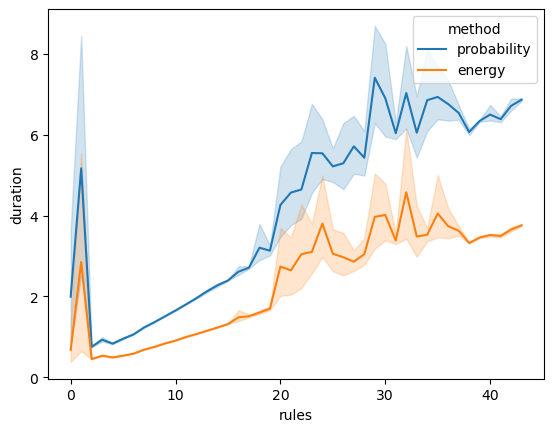

In [13]:
import seaborn as sb
import pandas as pd

df = pd.DataFrame(results)
sb.lineplot(df, x="rules", y="duration", hue="method")

In [16]:
results = []
a_ = []

# Train standard MLN
data = torch.load(join("predictions/wrn40/", f"data-{cfg.mln.train_on}-{seed:05d}.pt"))


for size, i in tqdm(list(product(range(1, 50), range(50)))):
    s = 1000 * size
    # print(size)
    d = torch.stack(
        [
            data["label-logits"].max(dim=1).indices,
            data["color-logits"].max(dim=1).indices,
            data["shape-logits"].max(dim=1).indices,
        ],
        dim=1,
    )[:s]

    # train mln
    with torch.no_grad():
        mln = MLN(
            constraints=rules,
            domain=[
                range(43),
                [0, 1, 2, 3],
                [0, 1, 2, 3, 4],
            ],
        )

        t1 = time.time()
        a = mln(d)
        a_.append(a.sum().item())

        t2 = time.time()

        results.append({"duration": (t2 - t1) * 1000, "size": size, "replica": i})

  0%|          | 0/2450 [00:00<?, ?it/s]

<Axes: xlabel='size', ylabel='duration'>

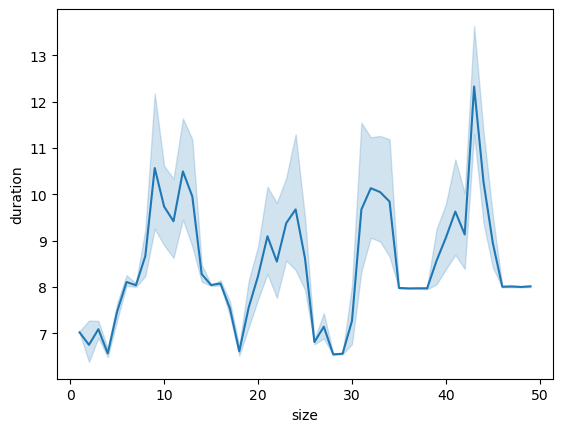

In [17]:
df = pd.DataFrame(results)
sb.lineplot(df, x="size", y="duration")

In [51]:
import time
from tqdm.auto import tqdm
from itertools import product
import torch


color_net = torch.load("models/wrn40/model-color-00000.pt")
label_net = torch.load("models/wrn40/model-label-00000.pt")
shape_net = torch.load("models/wrn40/model-shape-00000.pt")
color_net.eval()
label_net.eval()
shape_net.eval()


# a = mln(d)
# a_.append(a.sum().item())
mln = MLN(
    constraints=rules,
    domain=[
        range(43),
        [0, 1, 2, 3],
        [0, 1, 2, 3, 4],
    ],
)

mln.to("cuda")

mln = torch.compile(mln)
# Example networks
color_net = torch.compile(color_net.cuda())
shape_net = torch.compile(shape_net.cuda())
label_net = torch.compile(label_net.cuda())


results = []

prev = -1

for n_rules, i in tqdm(
    list(product([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048], range(100)))
):
    with torch.inference_mode():

        if n_rules != prev:
            # Warm-up runs (not timed)
            warmup_steps = 100
            print(f"Warmup for {n_rules}")
            for _ in range(warmup_steps):
                img = torch.randn(size=(n_rules, 3, 32, 32)).cuda()
                color, v_c = color_net(img).max(dim=1)
                shape, v_s = shape_net(img).max(dim=1)
                label, v_l = label_net(img).max(dim=1)
                conf = torch.stack([color, shape, label], dim=1).mean(dim=1)
                states = torch.stack([v_c, v_s, v_l], dim=1)
                r = (mln.prob(states) * conf).sum().cpu().item()
            prev = n_rules

        torch.cuda.synchronize()

        img = torch.randn(size=(n_rules, 3, 32, 32)).cuda()

        torch.cuda.synchronize()
        start_time = time.perf_counter()
        color, v_c = color_net(img).max(dim=1)
        shape, v_s = shape_net(img).max(dim=1)
        label, v_l = label_net(img).max(dim=1)
        conf = torch.stack([color, shape, label], dim=1).mean(dim=1)
        states = torch.stack([v_c, v_s, v_l], dim=1)
        r = (mln.prob(states) * conf).sum().cpu().item()
        torch.cuda.synchronize()
        end_time = time.perf_counter()

        results.append(
            {
                "duration": (end_time - start_time) * 1000,
                "size": n_rules,
                "replica": i,
                "energy": r,
                "method": "MLN",
            }
        )

        img = torch.randn(size=(n_rules, 3, 32, 32)).cuda()
        torch.cuda.synchronize()
        start_time = time.perf_counter()
        color, v_c = color_net(img).max(dim=1)
        shape, v_s = shape_net(img).max(dim=1)
        label, v_l = label_net(img).max(dim=1)
        conf = torch.stack([color, shape, label], dim=1).mean(dim=1)
        states = torch.stack([v_c, v_s, v_l], dim=1)
        r = (mln.energy(states) * conf).sum().cpu().item()
        torch.cuda.synchronize()
        end_time = time.perf_counter()

        results.append(
            {
                "duration": (end_time - start_time) * 1000,
                "size": n_rules,
                "replica": i,
                "energy": r,
                "method": "MLN(e)",
            }
        )

        img = torch.randn(size=(n_rules, 3, 32, 32)).cuda()
        torch.cuda.synchronize()
        start_time = time.perf_counter()
        color = color_net(img).max(dim=1).values
        shape = shape_net(img).max(dim=1).values
        label = label_net(img).max(dim=1).values
        states = torch.stack([color, shape, label], dim=1)
        r = states.mean(dim=1).sum().cpu().item()
        torch.cuda.synchronize()
        end_time = time.perf_counter()

        results.append(
            {
                "duration": (end_time - start_time) * 1000,
                "size": n_rules,
                "replica": i,
                "energy": r,
                "method": "Ensemble",
            }
        )

        img = torch.randn(size=(n_rules, 3, 32, 32)).cuda()
        torch.cuda.synchronize()
        start_time = time.perf_counter()
        color = label_net(img).max(dim=1).values
        # states = torch.stack([color, shape, label], dim=1)
        # r = mln.energy(states).sum().cpu().item()

        end_time = time.perf_counter()

        results.append(
            {
                "duration": (end_time - start_time) * 1000,
                "size": n_rules,
                "replica": i,
                "energy": r,
                "method": "MSP",
            }
        )

  0%|          | 0/1200 [00:00<?, ?it/s]

Warmup for 1
Warmup for 2
Warmup for 4
Warmup for 8
Warmup for 16
Warmup for 32
Warmup for 64
Warmup for 128
Warmup for 256
Warmup for 512
Warmup for 1024
Warmup for 2048


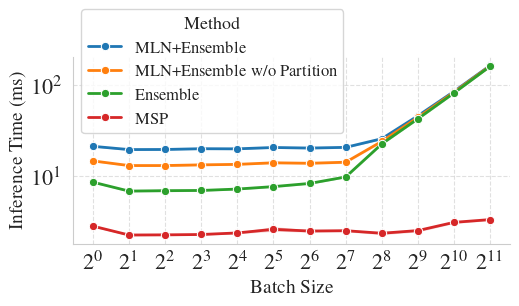

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb


sb.set_style("whitegrid")
gridline_style = {"color": "gray", "linestyle": "--", "linewidth": 0.5, "alpha": 0.3}

# Enable LaTeX rendering in matplotlib
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX to render text
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath, amssymb}",  # Load required packages,
        "pdf.fonttype": 42,  # Ensure fonts are stored as Type 42 (TrueType) for best quality in PDFs
        "ps.fonttype": 42,
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.serif": ["Times"],  # Set Times as the default serif font
    }
)
plt.rcParams.update(
    {
        "font.size": 24,  # General font size
        "axes.titlesize": 20,  # Title font size
        "axes.labelsize": 18,  # Axis label font size
        "xtick.labelsize": 16,  # X tick label font size
        "ytick.labelsize": 16,  # Y tick label font size
        "legend.fontsize": 14,  # Legend font size
    }
)
import math


df = pd.DataFrame(results)
df.to_csv("mln-latency.csv")

df["method"] = df["method"].replace("MLN", "MLN+Ensemble")
df["method"] = df["method"].replace("MLN(e)", "MLN+Ensemble w/o Partition")
# Set up the figure size for better visibility
plt.figure(figsize=(5, 3))

# Use seaborn for lineplot with improved labels
sb.lineplot(
    data=df,
    x="size",
    y="duration",
    hue="method",
    marker="o",
    linewidth=2,
    errorbar=("ci", 95),
)

# Add labels and a title
plt.xlabel("Batch Size", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
# plt.title('Latency vs. Input Size by Method', fontsize=16)


# Set y-axis to log scale
plt.yscale("log")
plt.xscale("log")

# Add a grid for better readability
plt.grid(True, linestyle="--", alpha=0.6)

# Adjust the legend for better readability
plt.legend(
    title="Method",
    fontsize=12,
    title_fontsize=13,
    loc="upper left",
    bbox_to_anchor=(0, 1.3),
)  #

plt.xticks(
    df["size"].unique(),
    labels=[f"$2^{{{int(math.log2(x)):.0f}}}$" for x in df["size"].unique()],
)

# plt.xticks([1,128,1024])
# plt.minorticks_on()
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(10))
# plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))

plt.tight_layout(pad=0)
sb.despine(top=True, right=True)
# Save the figure
plt.savefig("latency.pdf", bbox_inches="tight")

# Show the plot
plt.show()

In [53]:
df.tail()

,duration,size,replica,energy,method
4795,3.386019,2048,98,1.426938e+04,MSP
4796,165.629350,2048,99,1.711434e+01,MLN+Ensemble
4797,163.459700,2048,99,8.217495e-15,MLN+Ensemble w/o Partition
4798,161.985917,2048,99,1.422786e+04,Ensemble
4799,3.565371,2048,99,1.422786e+04,MSP


In [1]:
df.to_csv("/home/ki/mln-latency.csv")

NameError: name 'df' is not defined